In [1]:
import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from datetime import datetime
import mar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import geopandas as gpd

In [2]:
iyr=1980;fyr=2024
domain='GRf'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)  
print(latS,latN,lonW,lonE)

# Removed pixels on domain boundaries
k =10

36 41 67 78


In [3]:
# Kyzylsu Glacier coordinates:
kyz_lat = 39.4737011
kyz_lon = 73.543701

In [4]:
season_list = ["DJF", "MAM", "JJA", "SON"]

In [5]:
domain_2 = 'GRp'
# domain_3 = 'GRp_bug'

In [6]:
sourceData_1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/' + domain_2 +'/spin2/work/monthly/'
sourceData_2='/bettik/PROJECTS/pr-regional-climate/fainx/'
# sourceData_3='/bettik/PROJECTS/pr-regional-climate/santolam/'
folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/' + domain_2 +'/'

### Load MAR dataset

In [7]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRp.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

# Enlever k pixels sur les contours
ds_lon=ds_grF.LON[k:-k,k:-k]
ds_lat=ds_grF.LAT[k:-k,k:-k]
ds_SH=ds_grF.SH[k:-k,k:-k]
ds_ICE=ds_grF.ICE[k:-k,k:-k]

ds_lon = ds_lon.rename({"y": "Y", "x": "X"})
ds_lat = ds_lat.rename({"y": "Y", "x": "X"})
ds_SH = ds_SH.rename({"y": "Y", "x": "X"})
ds_ICE = ds_ICE.rename({"y": "Y", "x": "X"})

ds_lon = ds_lon.assign_coords(X=np.round(ds_lon.X.values))
ds_lon = ds_lon.assign_coords(Y=np.round(ds_lon.Y.values))

ds_lat = ds_lat.assign_coords(X=np.round(ds_lat.X.values))
ds_lat = ds_lat.assign_coords(Y=np.round(ds_lat.Y.values))

ds_SH = ds_SH.assign_coords(X=np.round(ds_SH.X.values))
ds_SH = ds_SH.assign_coords(Y=np.round(ds_SH.Y.values))

ds_ICE = ds_ICE.assign_coords(X=np.round(ds_ICE.X.values))
ds_ICE = ds_ICE.assign_coords(Y=np.round(ds_ICE.Y.values))

In [8]:
# Identifier les indices X et Y correspondant au point de grille ou se trouve le glacier Kyzylsu

# distance sur grille
dist = np.sqrt((ds_lat - kyz_lat)**2 + (ds_lon - kyz_lon)**2)

# index 1D du minimum
idx_1d = dist.argmin().item()

# conversion en indices 2D (Y, X)
iY, iX = np.unravel_index(idx_1d, dist.shape)

print("Caratéristique de la maille MAR ou se trouve le glacier Kyzylsu")
print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude :", ds_lat[iY, iX].item())
print("Longitude :", ds_lon[iY, iX].item())
print("Altitude :", ds_SH[iY, iX].item())
print("%ICE :", ds_ICE[iY, iX].item())

Caratéristique de la maille MAR ou se trouve le glacier Kyzylsu
Indice Y : 41
Indice X : 62
Latitude : 39.48607635498047
Longitude : 73.5234375
Altitude : 5241.6201171875
%ICE : 62.626258850097656


In [122]:
iY_med = iY -1
iX_med = iX -1

print("Caratéristique d'une  maille MAR d'altitude proche de l'altitude médiane du glacier Kyzylsu")
print("Indice Y :", iY_med)
print("Indice X :", iX_med)
print("Latitude :", ds_lat[iY_med, iX_med].item())
print("Longitude :", ds_lon[iY_med, iX_med].item())
print("Altitude :", ds_SH[iY_med, iX_med].item())
print("%ICE :", ds_ICE[iY_med, iX_med].item())

Caratéristique d'une  maille MAR d'altitude proche de l'altitude médiane du glacier Kyzylsu
Indice Y : 40
Indice X : 61
Latitude : 39.423954010009766
Longitude : 73.44086456298828
Altitude : 4540.13720703125
%ICE : 11.111111640930176


/tmp/ipykernel_84487/2988282445.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


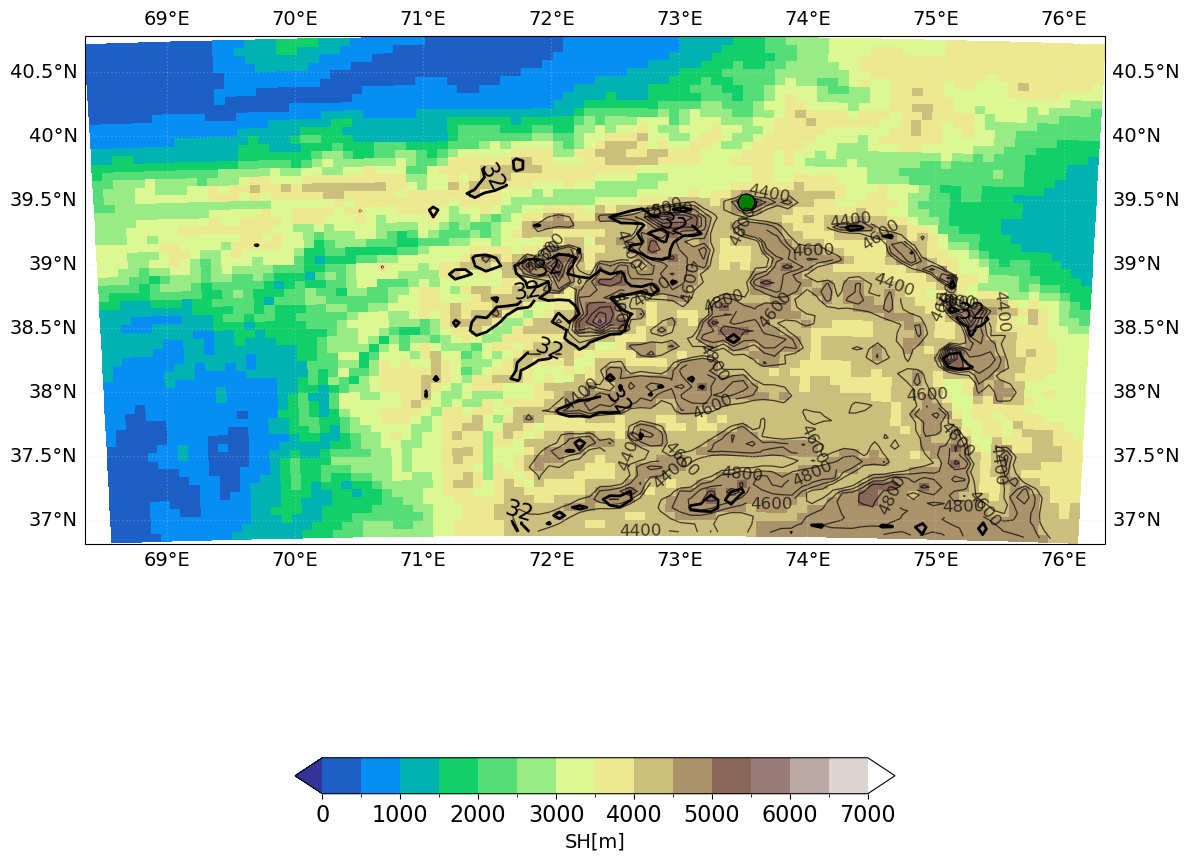

In [9]:
ice_level=32# % of ice on grid cell

clevs=np.arange(0,7500,500)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

# ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
#             levels=[10,ice_level,100],
#             hatches=['','X','X'],
#             colors="none",
#             transform=ccrs.PlateCarree())

#    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
ax.set_aspect(1.0)
SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[4400,4600,4800,5000,5200,5400,5600,5800,6000,6200,6400,6600,6800,7000],
                             colors="k", linewidths=0.9, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")
 
# ax.set_extent([71, 72, 39.4, 40], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="lightgray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# kyz Glacier: red dot
ax.plot(kyz_lon, kyz_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

# Identifier le point de grille ou se trouve Kyzylsu
ax.plot(ds_lon[iY, iX], ds_lat[iY, iX],
        marker='o', markersize=12,
        markeredgecolor='black', markerfacecolor='green',
        transform=ccrs.PlateCarree())

plt.show()

/tmp/ipykernel_84487/1615785452.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


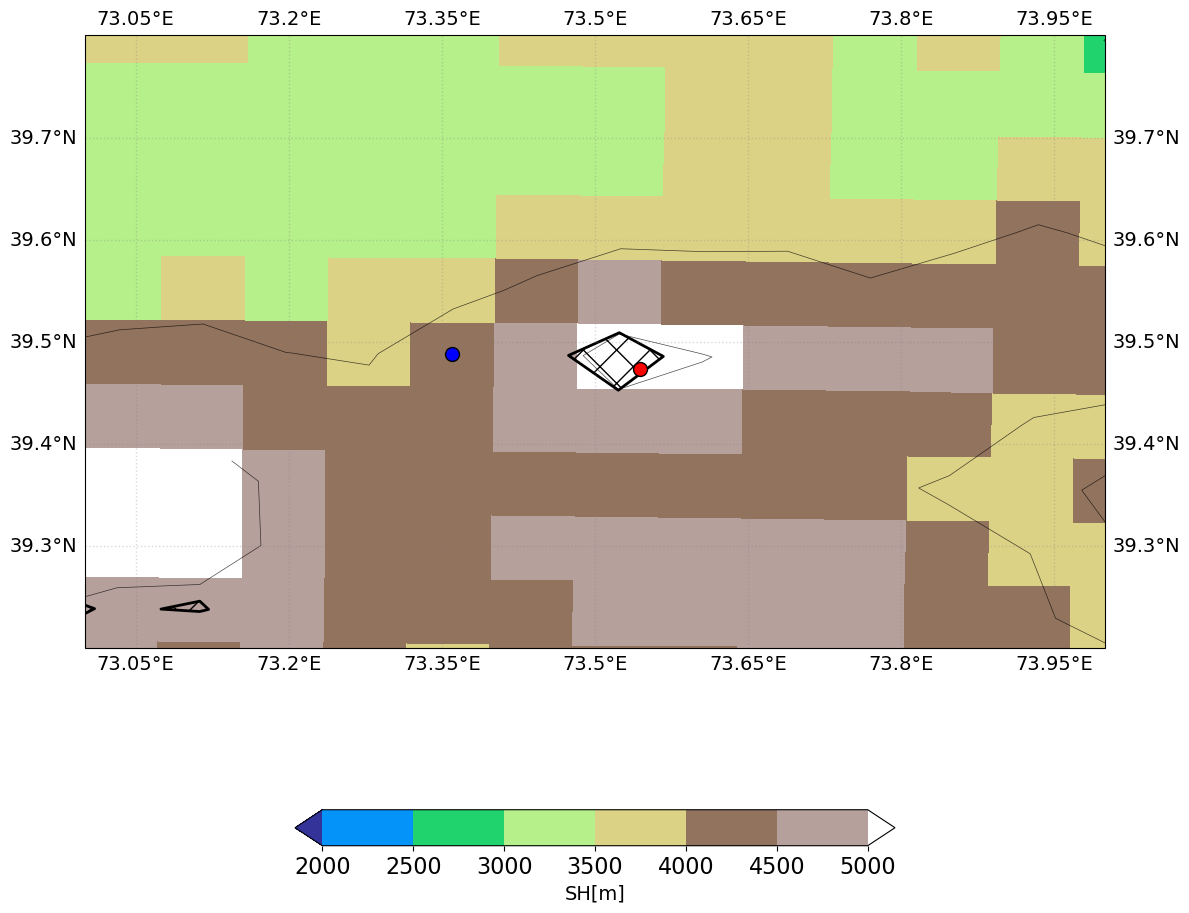

In [109]:
ice_level=40# % of ice on grid cell

clevs=np.arange(2000,5500,500)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
            levels=[10,ice_level,100],
            hatches=['','X','X'],
            colors="none",
            transform=ccrs.PlateCarree())

#    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
ax.set_aspect(1.0)
SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[1000,2000,3000,4000,5000,6000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")

# Latitude : 39.67844009399414
# Longitude : 71.48213958740234
ax.set_extent([73, 74, 39.2, 39.8], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# Kyzylsu Glacier : red dot
ax.plot(kyz_lon, kyz_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

# Cell of altitude~median Kyzylsu Glacier altitude: blue dot
ax.plot(ds_lon[iY_med, iX_med], ds_lat[iY_med, iX_med],
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='blue',
        transform=ccrs.PlateCarree())


plt.show()



### MAR datasets

# A ajouter ici : ds_SW mon mean


In [12]:
variable='TTZ'

ds_TTZ = xr.open_mfdataset(sourceData_1 + "TTZ_monmean_MARv3.14_ER5_spin2_GRp_*.nc").isel(ZTQLEV=0).TTZ.load()

ds_TTZ = ds_TTZ.assign_coords(X=np.round(ds_TTZ.X.values))
ds_TTZ = ds_TTZ.assign_coords(Y=np.round(ds_TTZ.Y.values))
ds_TTZ = ds_TTZ.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_TTZ = ds_TTZ[:,k:-k,k:-k]

In [13]:
variable='RF'

ds_RF = xr.open_mfdataset(sourceData_1 + "RF_monsum_MARv3.14_ER5_spin2_GRp_*.nc").RF.load()

ds_RF = ds_RF.assign_coords(X=np.round(ds_RF.X.values))
ds_RF = ds_RF.assign_coords(Y=np.round(ds_RF.Y.values))
ds_RF = ds_RF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RF = ds_RF[:,k:-k,k:-k]

In [14]:
variable='SF'

ds_SF = xr.open_mfdataset(sourceData_1 + "SF_monsum_MARv3.14_ER5_spin2_GRp_*.nc").SF.load()

ds_SF = ds_SF.assign_coords(X=np.round(ds_SF.X.values))
ds_SF = ds_SF.assign_coords(Y=np.round(ds_SF.Y.values))
ds_SF = ds_SF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SF = ds_SF[:,k:-k,k:-k]

In [15]:
variable='ME' 

ds_ME = xr.open_mfdataset(sourceData_1 + "ME_monsum_MARv3.14_ER5_spin2_GRp_*.nc").ME.isel(SECTOR1_1=0).load()

ds_ME = ds_ME.assign_coords(X=np.round(ds_ME.X.values))
ds_ME = ds_ME.assign_coords(Y=np.round(ds_ME.Y.values))
ds_ME = ds_ME.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_ME = ds_ME[:,k:-k,k:-k]
ds_ME = - ds_ME

In [16]:
variable='SMB' 
#"Surface Mass Balance (SMB~SF+RF-RU-SU-SW)" 

ds_SMB = xr.open_mfdataset(sourceData_1 + "SMB_monsum_MARv3.14_ER5_spin2_GRp_*.nc").SMB.isel(SECTOR=0).load()

ds_SMB = ds_SMB.assign_coords(X=np.round(ds_SMB.X.values))
ds_SMB = ds_SMB.assign_coords(Y=np.round(ds_SMB.Y.values))
ds_SMB = ds_SMB.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SMB = ds_SMB[:,k:-k,k:-k]

In [17]:
variable='SW' 
# Surface Water

ds_SW = xr.open_mfdataset(sourceData_1 + "SW_monsum_MARv3.14_ER5_spin2_GRp_*.nc").SW.isel(SECTOR1_1=0).load()

ds_SW = ds_SW.assign_coords(X=np.round(ds_SW.X.values))
ds_SW = ds_SW.assign_coords(Y=np.round(ds_SW.Y.values))
ds_SW = ds_SW.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SW = ds_SW[:,k:-k,k:-k]

In [18]:
variable='RU' 
# Run Off

ds_RU = xr.open_mfdataset(sourceData_1 + "RU_monsum_MARv3.14_ER5_spin2_GRp_*.nc").RU.isel(SECTOR=0).load()

ds_RU = ds_RU.assign_coords(X=np.round(ds_RU.X.values))
ds_RU = ds_RU.assign_coords(Y=np.round(ds_RU.Y.values))
ds_RU = ds_RU.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RU = ds_RU[:,k:-k,k:-k]

In [19]:
variable='RZ' 
# Refreezing // il faut un monSUM pour RW

ds_RZ = xr.open_mfdataset(sourceData_1 + "RZ_monsum_MARv3.14_ER5_spin2_GRp_*.nc").RZ.isel(SECTOR1_1=0).load()

ds_RZ = ds_RZ.assign_coords(X=np.round(ds_RZ.X.values))
ds_RZ = ds_RZ.assign_coords(Y=np.round(ds_RZ.Y.values))
ds_RZ = ds_RZ.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RZ = ds_RZ[:,k:-k,k:-k]

In [20]:
variable='SU' 
# SMB = SF - ME +RZ - SU - SW

ds_SU = -(ds_SF - (-ds_ME) + ds_RZ - ds_SW - ds_SMB)

## Sorties de MAR au point de Grille Kyzylsu Glacier

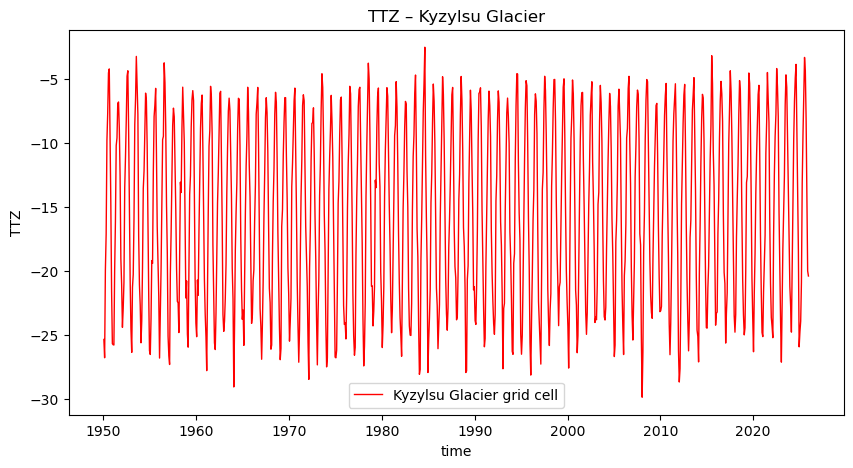

In [21]:
# TTZ at Jasgulem ice core site

plt.figure(figsize=(10,5))

ds_TTZ_kyz =  ds_TTZ.isel(Y=iY, X=iX)
ds_TTZ_kyz.plot(label="Kyzylsu Glacier grid cell", linewidth=1, color="red")

plt.legend(ncol=3)
plt.title("TTZ – Kyzylsu Glacier")
plt.ylabel("TTZ")
plt.show()

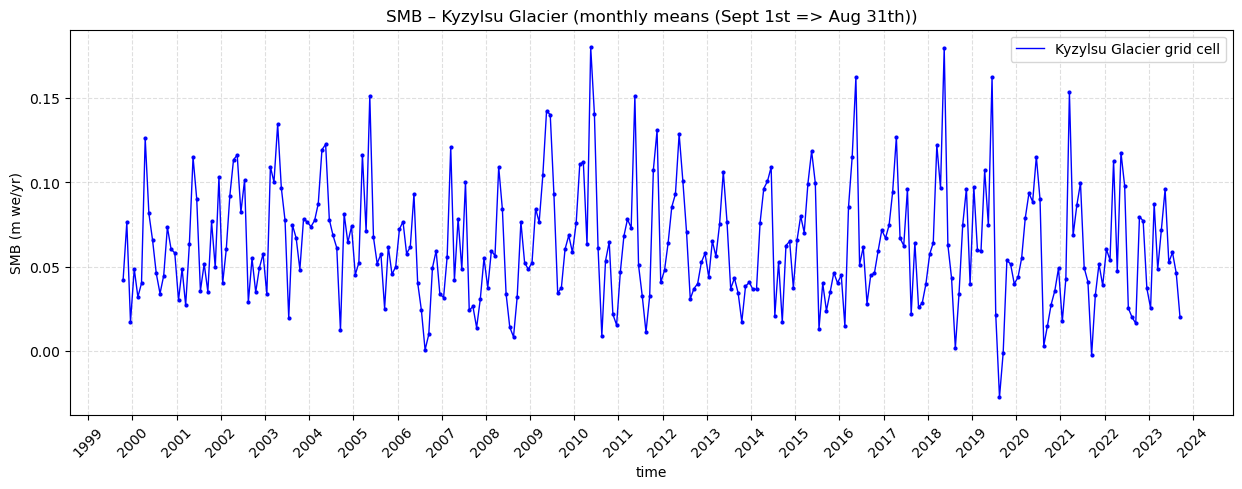

In [22]:
#SMB mensuel 

plt.figure(figsize=(15,5))

# Point précis Kyzylsu
ds_SMB_kyz = ds_SMB.isel(Y=iY, X=iX).sel(time=slice("1999-10-01", "2023-09-30"))/1000

ds_SMB_kyz.plot(label="Kyzylsu Glacier grid cell", linewidth=1, color="blue")

plt.plot(ds_SMB_kyz.time,
         ds_SMB_kyz,
         'o', color='blue', markersize=2)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.legend(ncol=3)
plt.title("SMB – Kyzylsu Glacier (monthly means (Sept 1st => Aug 31th))")
plt.ylabel("SMB (m we/yr)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


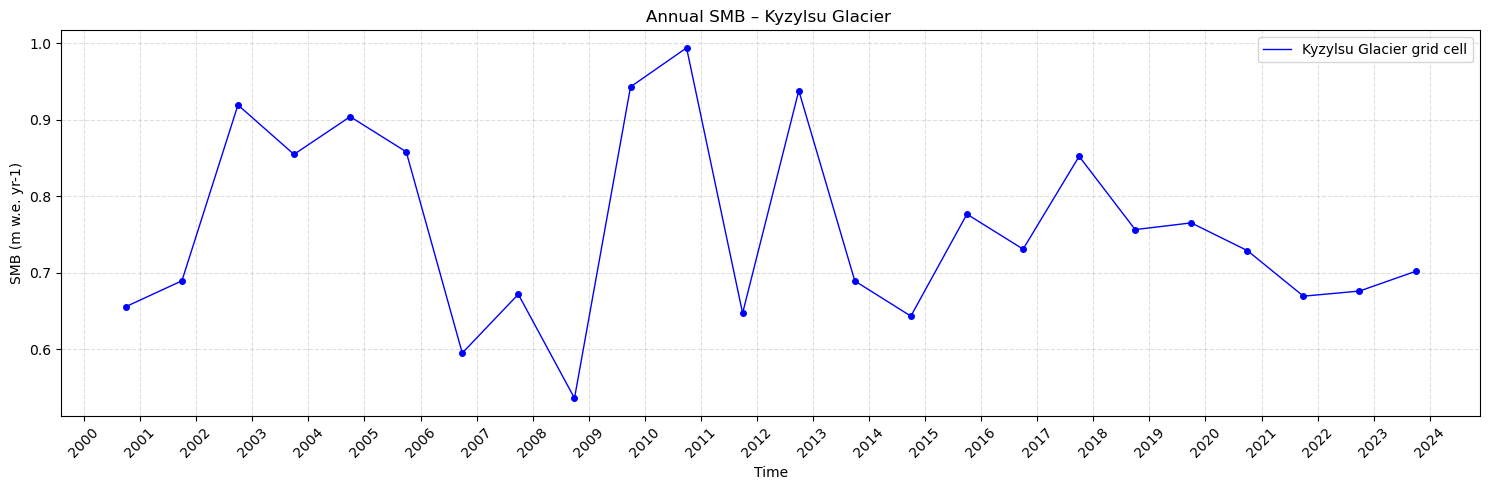

In [23]:
ds_SMB_kyz = (
    ds_SMB
    .isel(Y=iY, X=iX)
    .sel(time=slice("1999-10-01", "2023-09-30"))
    / 1000
)


ds_SMB_annual = ds_SMB_kyz.resample(time="A-SEP").sum()


plt.figure(figsize=(15, 5))

ds_SMB_annual.plot(
    label="Kyzylsu Glacier grid cell",
    linewidth=1,
    color="blue"
)

plt.plot(
    ds_SMB_annual.time,
    ds_SMB_annual,
    'o',
    color='blue',
    markersize=4
)

ax = plt.gca()

# Affichage d'une année par année
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)


plt.legend()

plt.title(
    "Annual SMB – Kyzylsu Glacier "
)

plt.ylabel("SMB (m w.e. yr-1)")
plt.xlabel("Time")

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'AS-SEP' is deprecated and will be removed in a future version, please use 'YS-SEP' instead.
  self.index_grouper = pd.Grouper(


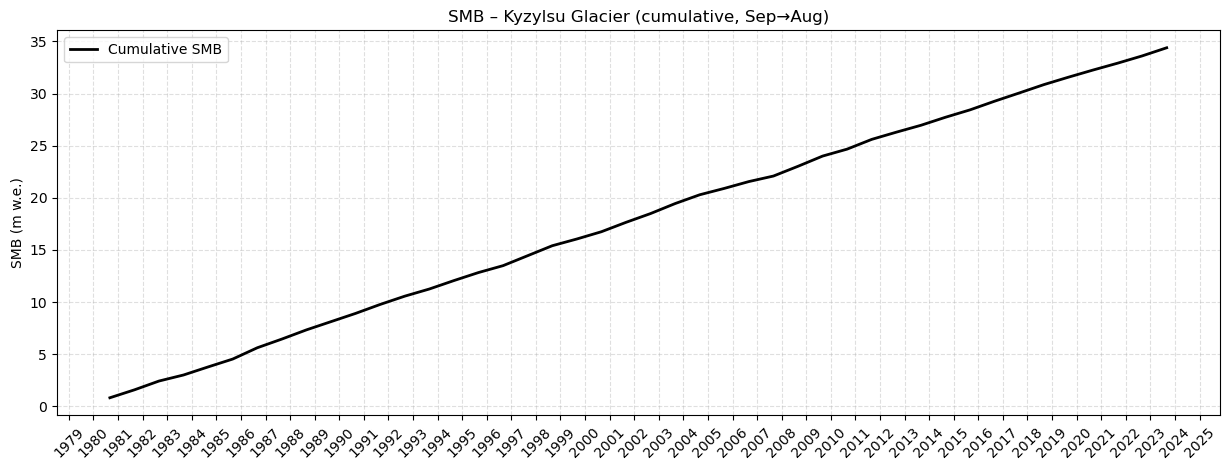

In [24]:
# =========================
# SMB annuel (Sep → Aug)
# =========================

ds_SMB_kyz = ds_SMB.isel(Y=iY, X=iX)

ds_SMB_kyz_annual = (
    ds_SMB_kyz
    .resample(time="AS-SEP")
    .sum()
    .sel(time=slice("1980-09-01", "2024-08-31"))
    / 1000  # m w.e.
)

# =========================
# CUMUL SMB
# =========================

ds_SMB_cum = ds_SMB_kyz_annual.cumsum(dim="time")

# =========================
# PLOT
# =========================

plt.figure(figsize=(15,5))

plt.plot(
    ds_SMB_cum.time,
    ds_SMB_cum,
    '-',
    color='black',
    linewidth=2,
    label="Cumulative SMB"
)

# =========================
# AXES
# =========================

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.title("SMB – Kyzylsu Glacier (cumulative, Sep→Aug)")
plt.ylabel("SMB (m w.e.)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()

## Composantes du SMB

In [25]:
# SMB = SF - ME + RZ - SU - SW

smb_dataset = {
    "SF": ds_SF,
    "ME": ds_ME,  
    "RZ": ds_RZ,
    "SU": ds_SU,
    "SW": ds_SW
}

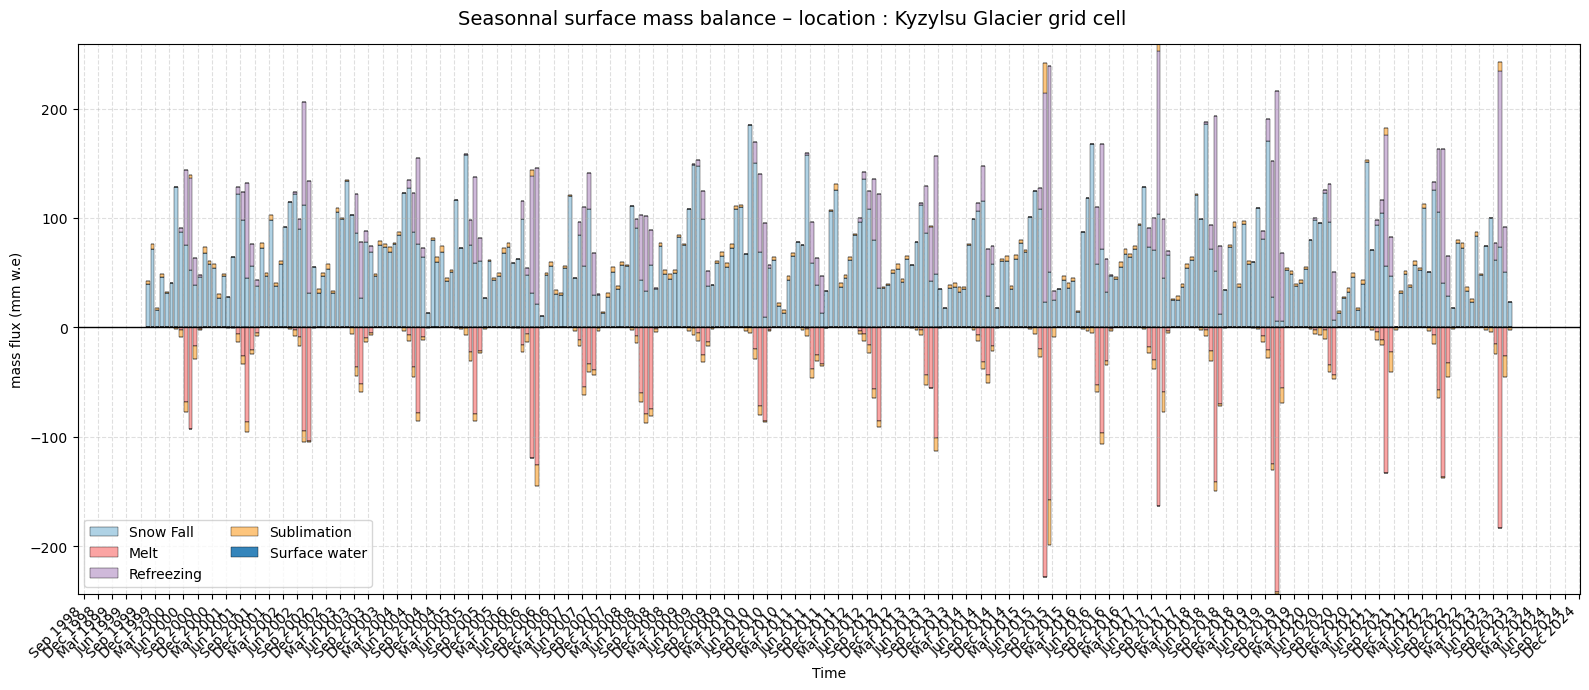

In [26]:
# Période cible
start_date = "1999-10-01"
end_date = "2023-09-30"

# Filtrer les données temporellement
smb_filtered = {}
for key, da in smb_dataset.items():
    smb_filtered[key] = da.sel(time=slice(start_date, end_date))

smb_jasg = {}
for key, da in smb_filtered.items():
    smb_jasg[key] = da.isel(Y=iY, X=iX)


# Composantes du SMB
components = ["SF", "ME", "RZ", "SU", "SW"]
labels = {
    "SF": "Snow Fall",
    "ME": "Melt",
    "RZ": "Refreezing",
    "SU": "Sublimation",
    "SW": "Surface water",
}

# Couleurs pour les histos
colors = {
    "SF": "#a6cee3",   # bleu clair 
    "ME": "#fb9a99",   # rouge clair
    "RZ": "#cab2d6",   # violet clair
    "SU": "#fdbf6f",   # orange clair
    "SW": "#1f78b4",   # bleu foncé 
}

# Temps et données
time = smb_jasg[components[0]].time.values
data = np.array([smb_jasg[comp].values for comp in components])

fig, ax = plt.subplots(figsize=(16, 7))

# Initialisation cumul
cumulative_pos = np.zeros_like(data[0])
cumulative_neg = np.zeros_like(data[0])

time_num = mdates.date2num(time)
width = np.median(np.diff(time_num)) * 0.8

for i, comp in enumerate(components):
    values = data[i]

    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(
        time,
        pos,
        width=width,
        bottom=cumulative_pos,
        color=colors[comp],
        label=labels[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    ax.bar(
        time,
        neg,
        width=width,
        bottom=cumulative_neg,
        color=colors[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    cumulative_pos += pos
    cumulative_neg += neg

# Ligne zéro
ax.axhline(0, color='black', linewidth=1)

# Labels
ax.set_ylabel("mass flux (mm w.e)")
ax.set_xlabel("Time")

# Format date
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")
fig.suptitle(f"Seasonnal surface mass balance – location : Kyzylsu Glacier grid cell ", fontsize=14)

ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()


ax.legend(ncol=2)

plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/grou

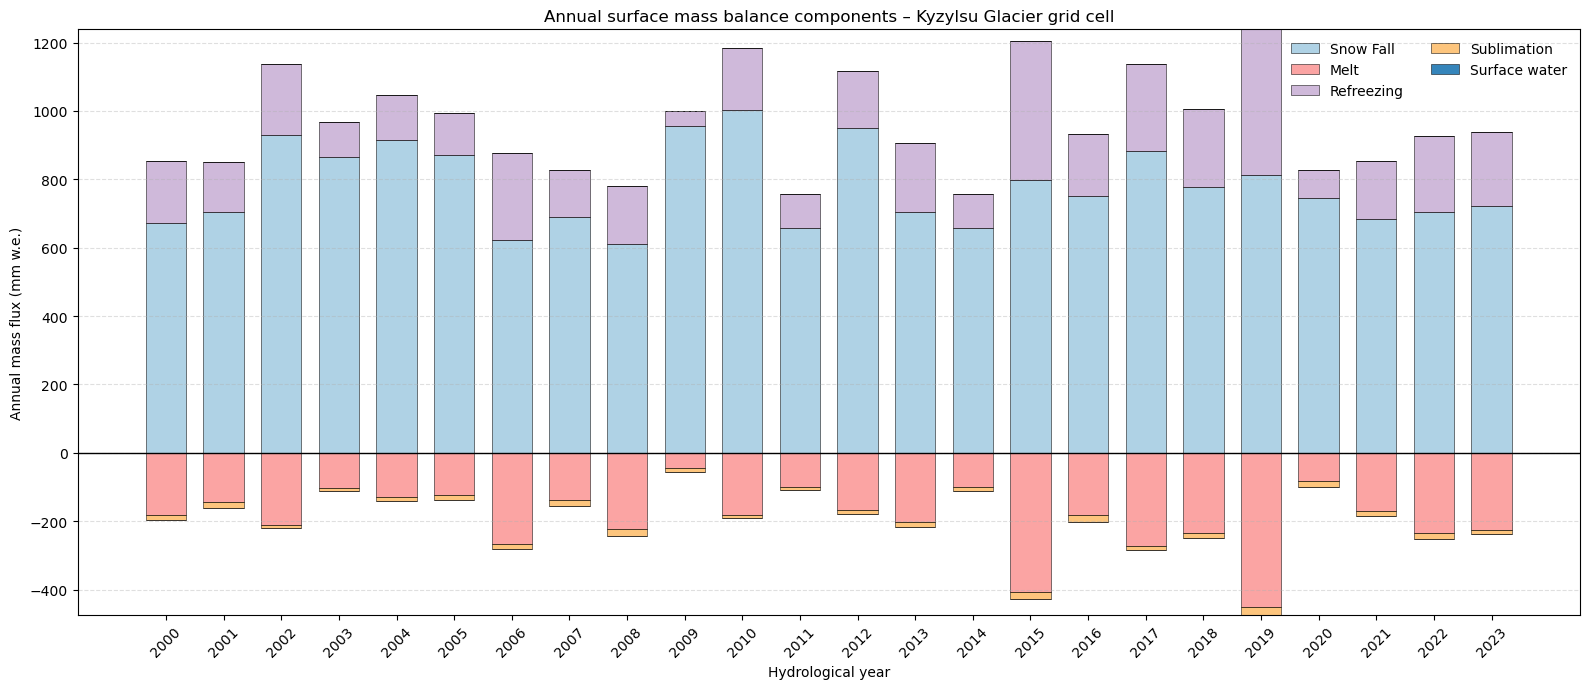

In [27]:
# --------------------------------------------------
# Période cible
# --------------------------------------------------
start_date = "1999-10-01"
end_date = "2023-09-30"

# --------------------------------------------------
# Filtrer et sélectionner la cellule Kyzylsu
# --------------------------------------------------
smb_jasg = {}

for key, da in smb_dataset.items():
    smb_jasg[key] = (
        da
        .sel(time=slice(start_date, end_date))
        .isel(Y=iY, X=iX)
    )

# --------------------------------------------------
# Composantes du SMB
# --------------------------------------------------
components = ["SF", "ME", "RZ", "SU", "SW"]

labels = {
    "SF": "Snow Fall",
    "ME": "Melt",
    "RZ": "Refreezing",
    "SU": "Sublimation",
    "SW": "Surface water",
}

colors = {
    "SF": "#a6cee3",
    "ME": "#fb9a99",
    "RZ": "#cab2d6",
    "SU": "#fdbf6f",
    "SW": "#1f78b4",
}

# --------------------------------------------------
# SOMME ANNUELLE HYDROLOGIQUE
# Octobre → Septembre
# --------------------------------------------------

smb_annual = {}

for comp in components:
    smb_annual[comp] = (
        smb_jasg[comp]
        .resample(time="A-SEP")
        .sum()
    )

# --------------------------------------------------
# Années hydrologiques
# --------------------------------------------------

years = smb_annual["SF"].time.dt.year.values

# --------------------------------------------------
# Figure
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 7))

# Cumuls positifs et négatifs
cumulative_pos = np.zeros(len(years))
cumulative_neg = np.zeros(len(years))

# Largeur des barres en années
width = 0.7

# --------------------------------------------------
# Histogrammes empilés
# --------------------------------------------------

for comp in components:

    values = smb_annual[comp].values

    # Positif
    pos = np.where(values > 0, values, 0)

    # Négatif
    neg = np.where(values < 0, values, 0)

    # Partie positive
    ax.bar(
        years,
        pos,
        width=width,
        bottom=cumulative_pos,
        color=colors[comp],
        label=labels[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.4
    )

    # Partie négative
    ax.bar(
        years,
        neg,
        width=width,
        bottom=cumulative_neg,
        color=colors[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.4
    )

    # Mise à jour des cumuls
    cumulative_pos += pos
    cumulative_neg += neg

# --------------------------------------------------
# Ligne zéro
# --------------------------------------------------

ax.axhline(
    0,
    color="black",
    linewidth=1
)

# --------------------------------------------------
# Axes
# --------------------------------------------------

ax.set_xlabel("Hydrological year")
ax.set_ylabel("Annual mass flux (mm w.e.)")

ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)

# --------------------------------------------------
# Titre
# --------------------------------------------------

ax.set_title(
    "Annual surface mass balance components – Kyzylsu Glacier grid cell"
)

# --------------------------------------------------
# Grille
# --------------------------------------------------

ax.grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.4
)

# --------------------------------------------------
# Légende
# --------------------------------------------------

ax.legend(
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()

## Observation of SMB at Kyzylsu

In [28]:
himap_folder = "/bettik/PROJECTS/pr-regional-climate/fainx/HMA_regions_Bolch/boundary_mountain_regions_hma_v3.shp"
regions = gpd.read_file(himap_folder)
regions = regions.to_crs(epsg=4326)

### RGI database

In [91]:
rgi_v6 = gpd.read_file(
    "/bettik/PROJECTS/pr-regional-climate/fainx/PAMIR_SMB_OBS/RGI/v6/13_rgi60_CentralAsia.shp"
)
print(rgi_v6.columns)

Index(['RGIId', 'GLIMSId', 'BgnDate', 'EndDate', 'CenLon', 'CenLat',
       'O1Region', 'O2Region', 'Area', 'Zmin', 'Zmax', 'Zmed', 'Slope',
       'Aspect', 'Lmax', 'Status', 'Connect', 'Form', 'TermType', 'Surging',
       'Linkages', 'Name', 'geometry'],
      dtype='object')


In [92]:
kyz_rgi = rgi_v6[rgi_v6['RGIId'] == 'RGI60-13.19847']
print(kyz_rgi["Zmin"], kyz_rgi["Zmed"], kyz_rgi["Zmax"], kyz_rgi["Area"], kyz_rgi["Area"], kyz_rgi["CenLon"], kyz_rgi["CenLat"])
# ca correspond pas exactement a Hyspo de la figure 4 du papier de Jouberton

19845    3450
Name: Zmin, dtype: int32 19845    4465
Name: Zmed, dtype: int32 19845    5319
Name: Zmax, dtype: int32 19845    8.201
Name: Area, dtype: float64 19845    8.201
Name: Area, dtype: float64 19845    71.430671
Name: CenLon, dtype: float64 19845    39.057327
Name: CenLat, dtype: float64


### Jouberton et al. (2025)

In [32]:
obs_folder ='/bettik/PROJECTS/pr-regional-climate/fainx/PAMIR_SMB_OBS/'
obs_file = 'Jouberton_2025_Figure_5_data.csv'

In [39]:
ds_obs = pd.read_csv(obs_folder + obs_file , sep=",")

In [43]:
ds_obs["Hydro_year_end"] = ds_obs["Hydro_year_start"] +1

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'AS-OCT' is deprecated and will be removed in a future version, please use 'YS-OCT' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'AS-OCT' is deprecated and will be removed in a future version, please use 'YS-OCT' instead.
  self.index_grouper = pd.Grouper(


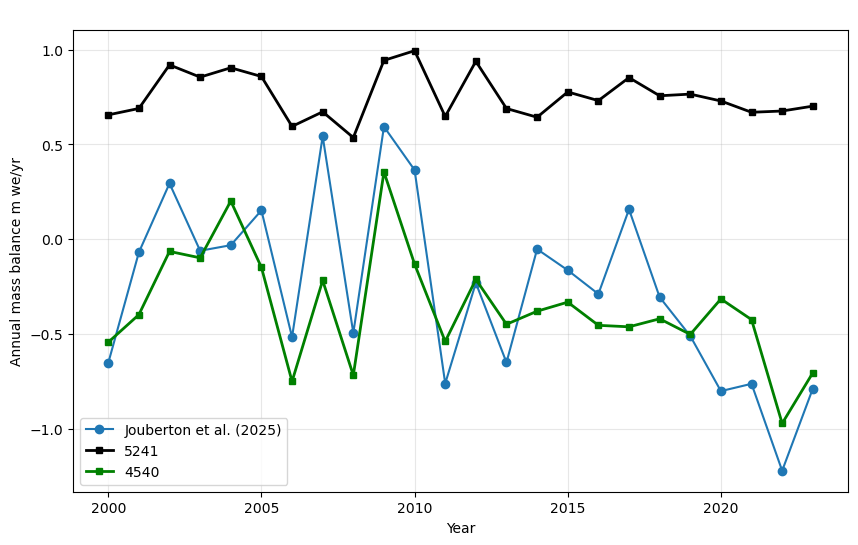

In [123]:
plt.figure(figsize=(10, 6))

smb_obs = ds_obs["Annual_GMB"]

# MAR at the exact location of the glacier
label_1 = int(ds_SH[iY, iX].item())

smb_mar = ds_SMB.isel(Y=iY, X=iX)

smb_mar_annual = (
    smb_mar
    .resample(time="AS-OCT") 
    .sum()
    .sel(time=slice("1999-10-01", "2023-09-30"))
    / 1000  # m w.e.
)

#AS = Annual Start, ici au 1er Oct. La date rapportée est celle du début de période
# Ajouter une année 
smb_mar_annual["time"] = (
    smb_mar_annual.time.to_index() + pd.DateOffset(years=1)
)

# MAR at lower altitude
label_2 = int(ds_SH[iY_med, iX_med].item())

smb_mar_med = ds_SMB.isel(Y=iY_med, X=iX_med)

smb_mar_annual_med = (
    smb_mar_med
    .resample(time="AS-OCT")
    .sum()
    .sel(time=slice("1999-10-01", "2023-09-30"))
    / 1000  # m w.e.
)

smb_mar_annual_med["time"] = (
    smb_mar_annual_med.time.to_index() + pd.DateOffset(years=1)
)


plt.plot(
    ds_obs["Hydro_year_end"],
    ds_obs["Annual_GMB"],
    marker="o",
    linewidth=1.5,
    label='Jouberton et al. (2025)'
)

plt.plot(
    smb_mar_annual.time.dt.year,
    smb_mar_annual,
    color="black",
    linewidth=2,
    marker="s",
    markersize=4,
    label= label_1
)

plt.plot(
    smb_mar_annual_med.time.dt.year,
    smb_mar_annual_med,
    color="green",
    linewidth=2,
    marker="s",
    markersize=4,
    label= label_2
)



plt.xlabel("Year")
plt.ylabel("Annual mass balance m we/yr")
plt.title(" ")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'AS-OCT' is deprecated and will be removed in a future version, please use 'YS-OCT' instead.
  self.index_grouper = pd.Grouper(


N      : 24
Mean   : 1.019 m w.e.
Median : 1.025 m w.e.
Std    : 0.407 m w.e.


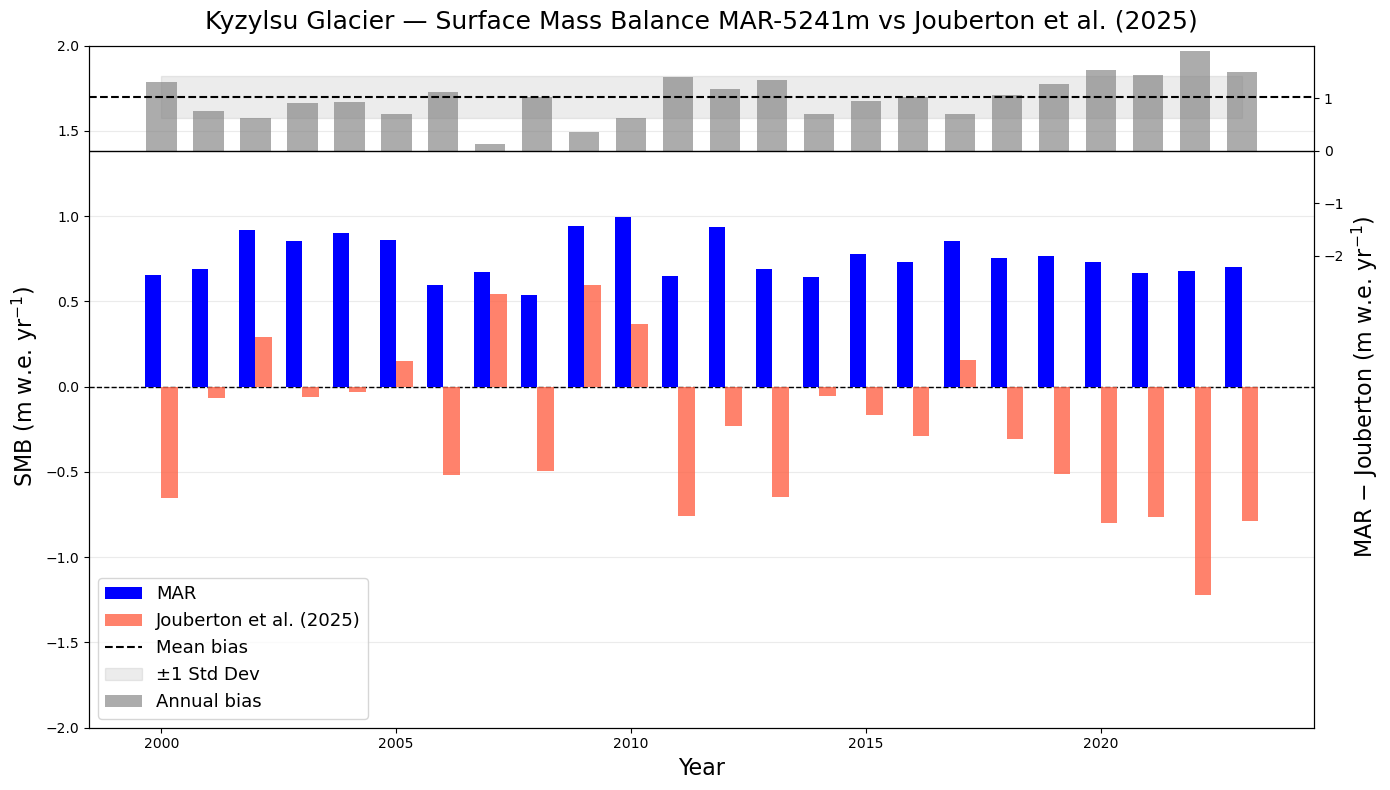

In [82]:
# plot at highest grid cell

# -------------------------
# Jouberton et al. 2025
# -------------------------
obs = ds_obs.copy()
obs = obs.rename(columns={"Hydro_year_end": "year"})

# -------------------------
# MAR
# -------------------------
ds_SMB_kyz = ds_SMB.isel(Y=iY, X=iX)

smb_mar_annual = (
    ds_SMB_kyz
    .resample(time="AS-OCT") 
    .sum()
    .sel(time=slice("1999-10-01", "2023-09-30"))
    / 1000  # m w.e.
)

#AS = Annual Start, ici au 1er Oct. La date rapportée est celle du début de période
# Ajouter une année 
smb_mar_annual["time"] = (
    smb_mar_annual.time.to_index() + pd.DateOffset(years=1)
)


mar = pd.DataFrame({
    "year": smb_mar_annual.time.dt.year.values,
    "MAR": smb_mar_annual.values
})

# -------------------------
# Fusion MAR / Jouberton
# -------------------------
comparison = pd.merge(
    obs,
    mar,
    on="year",
    how="inner"
)

# -------------------------
# Différence
# -------------------------
comparison["difference"] = comparison["MAR"] - comparison["Annual_GMB"]

n = comparison["difference"].count()

print(f"N      : {n}")
print(f"Mean   : {comparison['difference'].mean():.3f} m w.e.")
print(f"Median : {comparison['difference'].median():.3f} m w.e.")
print(f"Std    : {comparison['difference'].std():.3f} m w.e.")

# --------------------------------------------------
# Statistiques du biais
# --------------------------------------------------
bias = comparison["difference"]

mean_bias = bias.mean()
std_bias = bias.std()

# --------------------------------------------------
# Figure
# --------------------------------------------------
fig, ax1 = plt.subplots(figsize=(14, 8))

years = comparison["year"].values
x = years.astype(float)

# Largeur des barres
width = 0.35

# --------------------------------------------------
# 1. Barres MAR et WGMS
# --------------------------------------------------
ax1.bar(
    x - width/2,
    comparison["MAR"],
    width=width,
    color="blue",
    label="MAR",
    zorder=3
)

ax1.bar(
    x + width/2,
    comparison["Annual_GMB"],
    width=width,
    color="tomato",
    alpha=0.8,
    label="Jouberton et al. (2025)",
    zorder=3
)

# Ligne zéro de l'axe gauche
ax1.axhline(
    0,
    color="black",
    linewidth=1,
    linestyle="--",
    zorder=2
)

ax1.set_ylabel(
    "SMB (m w.e. yr$^{-1}$)",
    fontsize=16
)

ax1.set_xlabel(
    "Year",
    fontsize=16
)

# --------------------------------------------------
# 2. Axe du biais
# --------------------------------------------------
ax2 = ax1.twinx()

# Ligne y = 0 de l'axe du biais
ax2.axhline(
    0,
    color="black",
    linewidth=1,
    linestyle="-",
    zorder=2
)

# Histogramme du biais
ax2.bar(
    x,
    comparison["difference"],
    width=0.65,
    color="gray",
    alpha=0.65,
    label="Annual bias",
    zorder=1
)

# Moyenne du biais
ax2.axhline(
    mean_bias,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Mean bias",
    zorder=3
)

# Bande ± 1 Std Dev
ax2.fill_between(
    x,
    mean_bias - std_bias,
    mean_bias + std_bias,
    color="gray",
    alpha=0.15,
    label="±1 Std Dev",
    zorder=0
)

ax2.set_ylabel(
    "MAR − Jouberton (m w.e. yr$^{-1}$)",
    fontsize=16
)

# --------------------------------------------------
# 3. Limites Y
# --------------------------------------------------
ax1.set_ylim(-2, 2)

# Axe du biais
ax2.set_ylim(-11, 2)

# Graduations de l'axe du biais
ax2.set_yticks([1, 0, -1, -2])

# --------------------------------------------------
# 4. Décalage vertical de l'axe du biais
# --------------------------------------------------
ax2.spines["right"].set_position(("axes", 1.0))

# --------------------------------------------------
# 5. Axe X
# --------------------------------------------------

# --------------------------------------------------
# 6. Grille
# --------------------------------------------------
ax1.grid(
    axis="y",
    alpha=0.25,
    zorder=0
)

# --------------------------------------------------
# 7. Légende
# --------------------------------------------------
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="lower left",
    fontsize=13
)

# --------------------------------------------------
# 8. Titre
# --------------------------------------------------
ax1.set_title(
    "Kyzylsu Glacier — Surface Mass Balance MAR-5241m vs Jouberton et al. (2025)",
    fontsize=18,
    pad=12
)

plt.tight_layout()
plt.show()

N      : 24
Mean   : -0.101 m w.e.
Median : -0.140 m w.e.
Std    : 0.310 m w.e.


/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'AS-OCT' is deprecated and will be removed in a future version, please use 'YS-OCT' instead.
  self.index_grouper = pd.Grouper(


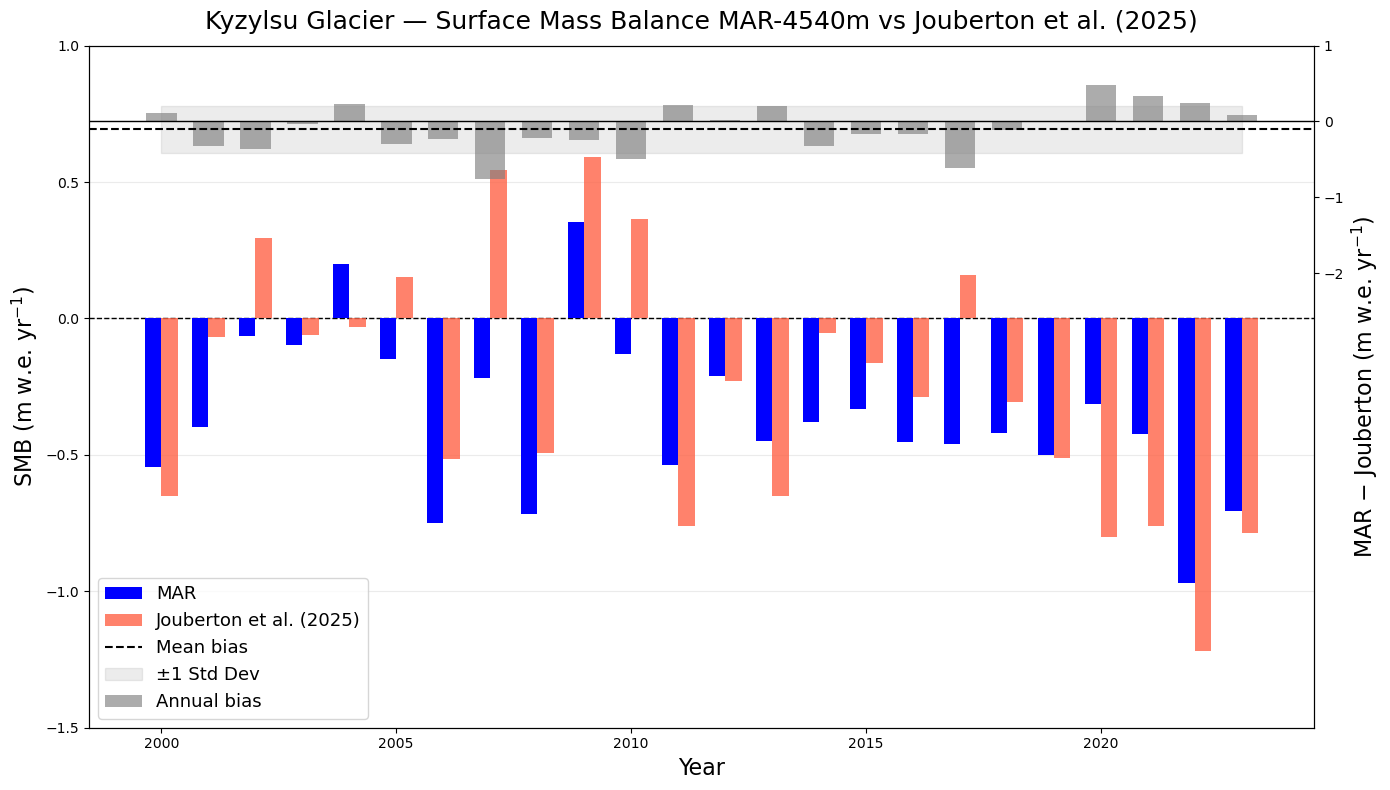

In [85]:
# plot at grid cell of median altitude close to real Mediane altitude of glacier

# -------------------------
# Jouberton et al. 2025
# -------------------------
obs = ds_obs.copy()
obs = obs.rename(columns={"Hydro_year_end": "year"})

# -------------------------
# MAR
# -------------------------
ds_SMB_kyz = ds_SMB.isel(Y=iY_med, X=iX_med)

smb_mar_annual = (
    ds_SMB_kyz
    .resample(time="AS-OCT") 
    .sum()
    .sel(time=slice("1999-10-01", "2023-09-30"))
    / 1000  # m w.e.
)

#AS = Annual Start, ici au 1er Oct. La date rapportée est celle du début de période
# Ajouter une année 
smb_mar_annual["time"] = (
    smb_mar_annual.time.to_index() + pd.DateOffset(years=1)
)


mar = pd.DataFrame({
    "year": smb_mar_annual.time.dt.year.values,
    "MAR": smb_mar_annual.values
})

# -------------------------
# Fusion MAR / Jouberton
# -------------------------
comparison = pd.merge(
    obs,
    mar,
    on="year",
    how="inner"
)

# -------------------------
# Différence
# -------------------------
comparison["difference"] = comparison["MAR"] - comparison["Annual_GMB"]

n = comparison["difference"].count()

print(f"N      : {n}")
print(f"Mean   : {comparison['difference'].mean():.3f} m w.e.")
print(f"Median : {comparison['difference'].median():.3f} m w.e.")
print(f"Std    : {comparison['difference'].std():.3f} m w.e.")

# --------------------------------------------------
# Statistiques du biais
# --------------------------------------------------
bias = comparison["difference"]

mean_bias = bias.mean()
std_bias = bias.std()

# --------------------------------------------------
# Figure
# --------------------------------------------------
fig, ax1 = plt.subplots(figsize=(14, 8))

years = comparison["year"].values
x = years.astype(float)

# Largeur des barres
width = 0.35

# --------------------------------------------------
# 1. Barres MAR et WGMS
# --------------------------------------------------
ax1.bar(
    x - width/2,
    comparison["MAR"],
    width=width,
    color="blue",
    label="MAR",
    zorder=3
)

ax1.bar(
    x + width/2,
    comparison["Annual_GMB"],
    width=width,
    color="tomato",
    alpha=0.8,
    label="Jouberton et al. (2025)",
    zorder=3
)

# Ligne zéro de l'axe gauche
ax1.axhline(
    0,
    color="black",
    linewidth=1,
    linestyle="--",
    zorder=2
)

ax1.set_ylabel(
    "SMB (m w.e. yr$^{-1}$)",
    fontsize=16
)

ax1.set_xlabel(
    "Year",
    fontsize=16
)

# --------------------------------------------------
# 2. Axe du biais
# --------------------------------------------------
ax2 = ax1.twinx()

# Ligne y = 0 de l'axe du biais
ax2.axhline(
    0,
    color="black",
    linewidth=1,
    linestyle="-",
    zorder=2
)

# Histogramme du biais
ax2.bar(
    x,
    comparison["difference"],
    width=0.65,
    color="gray",
    alpha=0.65,
    label="Annual bias",
    zorder=1
)

# Moyenne du biais
ax2.axhline(
    mean_bias,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Mean bias",
    zorder=3
)

# Bande ± 1 Std Dev
ax2.fill_between(
    x,
    mean_bias - std_bias,
    mean_bias + std_bias,
    color="gray",
    alpha=0.15,
    label="±1 Std Dev",
    zorder=0
)

ax2.set_ylabel(
    "MAR − Jouberton (m w.e. yr$^{-1}$)",
    fontsize=16
)

# --------------------------------------------------
# 3. Limites Y
# --------------------------------------------------
ax1.set_ylim(-1.5, 1)

# Axe du biais
ax2.set_ylim(-8, 1)

# Graduations de l'axe du biais
ax2.set_yticks([1, 0, -1, -2])

# --------------------------------------------------
# 4. Décalage vertical de l'axe du biais
# --------------------------------------------------
ax2.spines["right"].set_position(("axes", 1.0))

# --------------------------------------------------
# 5. Axe X
# --------------------------------------------------

# --------------------------------------------------
# 6. Grille
# --------------------------------------------------
ax1.grid(
    axis="y",
    alpha=0.25,
    zorder=0
)

# --------------------------------------------------
# 7. Légende
# --------------------------------------------------
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="lower left",
    fontsize=13
)

# --------------------------------------------------
# 8. Titre
# --------------------------------------------------
ax1.set_title(
    "Kyzylsu Glacier — Surface Mass Balance MAR-4540m vs Jouberton et al. (2025)",
    fontsize=18,
    pad=12
)

plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'AS-OCT' is deprecated and will be removed in a future version, please use 'YS-OCT' instead.
  self.index_grouper = pd.Grouper(


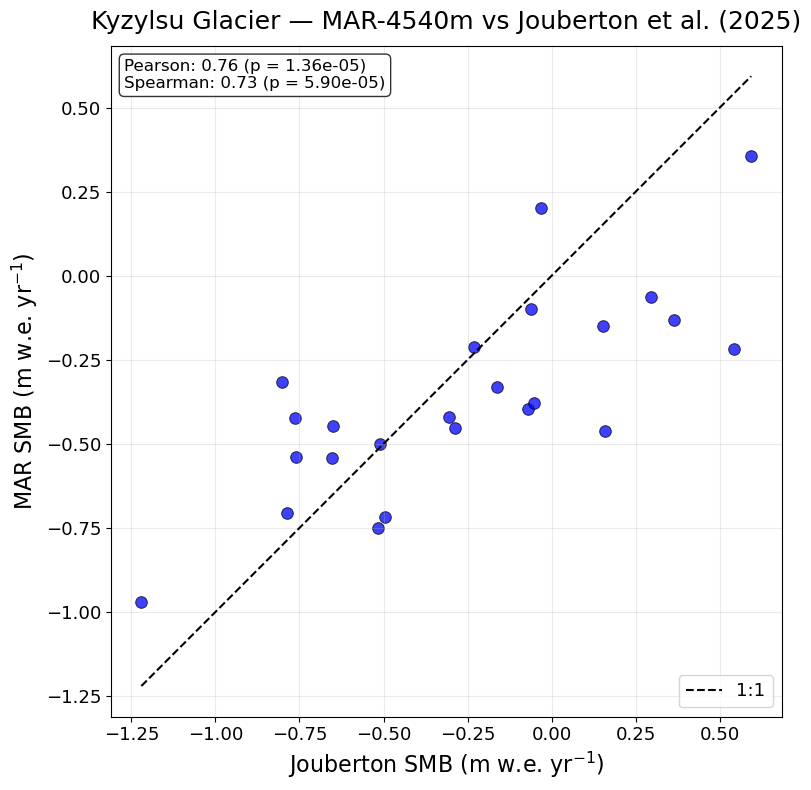

In [90]:
# plot at grid cell of median altitude close to real Mediane altitude of glacier

# -------------------------
# Jouberton et al. 2025
# -------------------------
obs = ds_obs.copy()
obs = obs.rename(columns={"Hydro_year_end": "year"})

# -------------------------
# MAR
# -------------------------
ds_SMB_kyz = ds_SMB.isel(Y=iY_med, X=iX_med)

smb_mar_annual = (
    ds_SMB_kyz
    .resample(time="AS-OCT") 
    .sum()
    .sel(time=slice("1999-10-01", "2023-09-30"))
    / 1000  # m w.e.
)

#AS = Annual Start, ici au 1er Oct. La date rapportée est celle du début de période
# Ajouter une année 
smb_mar_annual["time"] = (
    smb_mar_annual.time.to_index() + pd.DateOffset(years=1)
)


mar = pd.DataFrame({
    "year": smb_mar_annual.time.dt.year.values,
    "MAR": smb_mar_annual.values
})

# -------------------------
# Comparaison MAR / WGMS
# -------------------------
comparison = pd.merge(
    obs,
    mar,
    on="year",
    how="inner"
)

# Supprimer les années avec des valeurs manquantes
comparison = comparison.dropna(
    subset=["MAR", "Annual_GMB"]
)

# -------------------------
# Calcul des coefficients de corrélation et des p-values
# -------------------------
pearson_corr, pearson_p = stats.pearsonr(comparison["Annual_GMB"], comparison["MAR"])
spearman_corr, spearman_p = stats.spearmanr(comparison["Annual_GMB"], comparison["MAR"])

# -------------------------
# Scatter plot
# -------------------------
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    comparison["Annual_GMB"],
    comparison["MAR"],
    s=70,
    color="blue",
    alpha=0.75,
    edgecolor="black",
    linewidth=0.7,
)

# -------------------------
# Droite 1:1
# -------------------------
min_val = min(
    comparison["Annual_GMB"].min(),
    comparison["MAR"].min()
)

max_val = max(
    comparison["Annual_GMB"].max(),
    comparison["MAR"].max()
)

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="1:1"
)

# -------------------------
# Annotation des coefficients de corrélation et des p-values
# -------------------------
correlation_text = (
    f"Pearson: {pearson_corr:.2f} (p = {pearson_p:.2e})\n"
    f"Spearman: {spearman_corr:.2f} (p = {spearman_p:.2e})"
)
ax.text(
    0.02, 0.98,  # Position (x, y) en coordonnées normalisées
    correlation_text,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# -------------------------
# Labels
# -------------------------
ax.set_xlabel(
    "Jouberton SMB (m w.e. yr$^{-1}$)",
    fontsize=16
)

ax.set_ylabel(
    "MAR SMB (m w.e. yr$^{-1}$)",
    fontsize=16
)

ax.tick_params(
    axis="both",
    labelsize=13
)

# -------------------------
# Grille
# -------------------------
ax.grid(
    alpha=0.25
)

# -------------------------
# Aspect identique
# -------------------------
ax.set_aspect(
    "equal",
    adjustable="box"
)

# -------------------------
# Titre
# -------------------------
ax.set_title(
    "Kyzylsu Glacier — MAR-4540m vs Jouberton et al. (2025)",
    fontsize=18,
    pad=12
)

# -------------------------
# Légende
# -------------------------
ax.legend(
    fontsize=13
)

plt.tight_layout()
plt.show()